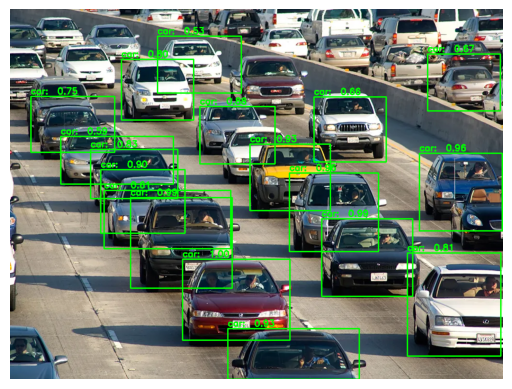

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#load pretrained CNN model (MobileNetSSD)
net = cv2.dnn.readNetFromCaffe(
    r"C:\Users\athni\Downloads\MobileNetSSD_deploy.prototxt",
    r"C:\Users\athni\Downloads\MobileNetSSD_deploy.caffemodel")

classes = ["background","aeroplane","bicycle","bird","boat","bottle",
          "bus","car","cat","chair","cow","dog","horse","motorbike",
          "person","sheep","sofa","train","tvmonitor"]

img = cv2.imread(r"C:\Users\athni\Downloads\highway-traffic.jpeg")

if img is None:
    print("Error image not found")
    exit()

h,w = img.shape[:2]

#preprocessing image
blob = cv2.dnn.blobFromImage(img,0.0078, (300, 300), 127.5)

#pass input to network
net.setInput(blob)

#Get detections
detections = net.forward()

#loop through detections
for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]
    
    if confidence > 0.5:
        class_id = int(detections[0, 0, i, 1])
        
        if classes[class_id] == "car":
            
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            x1, y1, x2, y2 = box.astype("int")
            
            #Draw bounding box
            cv2.rectangle(img, (x1,y1), (x2,y2), (0, 255, 0), 2)
            
            #label
            label = f"car: {confidence: .2f}"
            cv2.putText(img, label, (x1, y1 - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()